# 四只股票金融数据分析大作业

**标的：** GOOGL（谷歌）、AVGO（博通）、SLV（白银 ETF）、NVDA（英伟达）  
**数据：** 近两年日线收盘价  
**工具：** Pandas、NumPy、yfinance、matplotlib

In [1]:
import sys
from pathlib import Path

for candidate in [Path.cwd(), Path.cwd().parent]:
    if (candidate / "src" / "config.py").exists():
        sys.path.insert(0, str(candidate))
        PROJECT_ROOT = candidate
        break
else:
    raise RuntimeError("Cannot find project root (src/config.py)")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from src.config import TICKERS, IMAGES_DIR
from src.data_fetch import run_pipeline, load_raw, build_close_wide
from src.analysis import run_full_analysis, load_prices_wide
from src.plotting import generate_all_figures
from src.utils import summary_stats, vectorized_summary, log_returns_from_prices

sns.set_theme(style="whitegrid")
print("Project root:", PROJECT_ROOT)
print("Tickers:", TICKERS)

Project root: C:\Users\ltz\Projects\financial-analysis
Tickers: ['GOOGL', 'AVGO', 'SLV', 'NVDA']


## 第一步：数据采集与清洗

使用 `yfinance` 批量下载数据，保存 CSV，再合并为收盘价宽表。

In [2]:
# 若 yfinance 限流，改为 run_pipeline(demo=True)
USE_DEMO = True  # 有网络且未限流时改为 False
prices = run_pipeline(demo=USE_DEMO)
prices.head()

,GOOGL,AVGO,SLV,NVDA
2024-07-09,140.816887,1218.793552,22.143725,444.758844
2024-07-10,138.230121,1212.813086,23.021128,450.987705
2024-07-11,140.145731,1157.377310,22.265443,426.524575
2024-07-12,142.567472,1144.719038,22.264998,449.451855
2024-07-15,137.610596,1157.149775,22.447781,442.192204


In [3]:
if USE_DEMO:
    print("Demo 模式：无 raw CSV，展示宽表中 GOOGL 收盘价描述统计")
    display(prices["GOOGL"].describe().to_frame("GOOGL"))
else:
    sample = load_raw("GOOGL")
    print("--- head ---")
    display(sample.head())
    print("--- info ---")
    sample.info()
    print("--- describe ---")
    display(sample.describe())

Demo 模式：无 raw CSV，展示宽表中 GOOGL 收盘价描述统计


,GOOGL
count,504.000000
mean,134.920956
std,10.530858
min,111.203512
25%,126.026181
50%,134.541473
75%,143.508446
max,162.541933


## 第二步：收益率与 NumPy 向量化

简单收益率 `pct_change()`，对数收益率 `np.log()`，统计量用 `np.mean/std/var`，累计收益用 `np.cumsum()`。

In [4]:
results = run_full_analysis(prices)
rets = results["simple_returns"]
log_rets = results["log_returns"]

print("简单收益率（前 5 行）:")
display(rets.head())

print("\n手写函数 summary_stats:")
display(results["stats_loop"].round(6))

print("\nNumPy 广播 vectorized_summary（应一致）:")
display(results["stats_broadcast"].round(6))

most_volatile = results["stats_loop"]["std"].idxmax()
print(f"\n波动最大（日收益标准差最高）: {most_volatile}")

简单收益率（前 5 行）:


,GOOGL,AVGO,SLV,NVDA
2024-07-10,-0.018370,-0.004907,0.039623,0.014005
2024-07-11,0.013858,-0.045708,-0.032826,-0.054243
2024-07-12,0.017280,-0.010937,-0.000020,0.053754
2024-07-15,-0.034769,0.010859,0.008209,-0.016152
2024-07-16,-0.023089,-0.026811,-0.019970,0.037319



手写函数 summary_stats:


,mean,std,var
GOOGL,0.000106,0.017327,0.000300
AVGO,0.001451,0.026141,0.000683
SLV,-0.001388,0.022403,0.000502
NVDA,0.001799,0.033973,0.001154



NumPy 广播 vectorized_summary（应一致）:


,mean,std,var
GOOGL,0.000106,0.017327,0.000300
AVGO,0.001451,0.026141,0.000683
SLV,-0.001388,0.022403,0.000502
NVDA,0.001799,0.033973,0.001154



波动最大（日收益标准差最高）: NVDA


## 第二步补充：正态性与平稳性检验

- **Jarque-Bera**（`scipy.stats`）：检验日收益是否服从正态分布，H0 为正态；金融日收益通常尖峰厚尾，多在 5% 水平下拒绝 H0。
- **ADF**（`statsmodels`）：检验序列是否存在单位根；价格水平通常非平稳，收益率序列通常平稳。

In [5]:
print("Jarque-Bera 正态性检验（日简单收益）:")
display(results["normality_tests"].round(4))

print("\nADF 平稳性检验 — 价格水平:")
display(results["adf_price_tests"].round(4))

print("\nADF 平稳性检验 — 日收益:")
display(results["adf_return_tests"].round(4))

reject_norm = results["normality_tests"]["reject_normal_5pct"].sum()
nonstationary_prices = (~results["adf_price_tests"]["stationary_5pct"]).sum()
stationary_returns = results["adf_return_tests"]["stationary_5pct"].sum()
print(
    f"\n小结: {reject_norm}/{len(TICKERS)} 只标的拒绝正态性; "
    f"价格非平稳 {nonstationary_prices}/{len(TICKERS)}; "
    f"收益平稳 {stationary_returns}/{len(TICKERS)}"
)

Jarque-Bera 正态性检验（日简单收益）:


,jb_stat,p_value,reject_normal_5pct
GOOGL,0.8539,0.6525,False
AVGO,2.4226,0.2978,False
SLV,2.8620,0.2391,False
NVDA,0.4148,0.8127,False



ADF 平稳性检验 — 价格水平:


,kind,adf_stat,p_value,stationary_5pct
GOOGL,price,-2.7657,0.0633,False
AVGO,price,-1.5082,0.5295,False
SLV,price,-0.4785,0.8962,False
NVDA,price,-0.7414,0.8357,False



ADF 平稳性检验 — 日收益:


,kind,adf_stat,p_value,stationary_5pct
GOOGL,return,-20.2340,0.0,True
AVGO,return,-16.9154,0.0,True
SLV,return,-9.0890,0.0,True
NVDA,return,-11.3869,0.0,True



小结: 0/4 只标的拒绝正态性; 价格非平稳 4/4; 收益平稳 4/4


In [6]:
cum_log = results["cumulative_log_return"]
fig, ax = plt.subplots(figsize=(10, 4))
for col in cum_log.columns:
    cum_log[col].plot(ax=ax, label=col)
ax.set_title("累计对数收益曲线")
ax.legend()
plt.tight_layout()
plt.show()

C:\Users\ltz\AppData\Local\Temp\ipykernel_18280\603607697.py:7: UserWarning: Glyph 32047 (\N{CJK UNIFIED IDEOGRAPH-7D2F}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\ltz\AppData\Local\Temp\ipykernel_18280\603607697.py:7: UserWarning: Glyph 35745 (\N{CJK UNIFIED IDEOGRAPH-8BA1}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\ltz\AppData\Local\Temp\ipykernel_18280\603607697.py:7: UserWarning: Glyph 23545 (\N{CJK UNIFIED IDEOGRAPH-5BF9}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\ltz\AppData\Local\Temp\ipykernel_18280\603607697.py:7: UserWarning: Glyph 25968 (\N{CJK UNIFIED IDEOGRAPH-6570}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\ltz\AppData\Local\Temp\ipykernel_18280\603607697.py:7: UserWarning: Glyph 25910 (\N{CJK UNIFIED IDEOGRAPH-6536}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\ltz\AppData\Local\Temp\ipykernel_18280\603607697.py:7: UserWarning: Glyph 30410 (\N{CJK UNIFIED IDEOGRAPH-76CA}) missing from font(s) Ar

## 第三步：滚动窗口、相关性与时间序列

- 20 / 60 日移动平均线  
- 20 日滚动波动率  
- 收益率相关矩阵  
- `groupby` 月均收益 vs `resample` 月末复合收益

In [7]:
ma = results["moving_averages"]
display(ma[[c for c in ma.columns if "NVDA" in c]].tail())

print("相关性矩阵:")
display(results["correlation"].round(3))

tech = ["GOOGL", "AVGO", "NVDA"]
tech_corr = results["correlation"].loc[tech, tech].values[np.triu_indices(3, k=1)]
slv_corr = results["correlation"].loc["SLV", tech].mean()
print(f"科技股之间平均相关系数: {tech_corr.mean():.3f}")
print(f"SLV 与科技股平均相关系数: {slv_corr:.3f}")

,NVDA_MA20,NVDA_MA60
2026-06-08,802.201483,735.814188
2026-06-09,803.574652,737.738044
2026-06-10,804.948238,739.527860
2026-06-11,807.417436,740.579600
2026-06-12,808.435056,741.793995


相关性矩阵:


,GOOGL,AVGO,SLV,NVDA
GOOGL,1.000,-0.002,-0.061,0.001
AVGO,-0.002,1.000,-0.011,0.067
SLV,-0.061,-0.011,1.000,-0.066
NVDA,0.001,0.067,-0.066,1.000


科技股之间平均相关系数: 0.022
SLV 与科技股平均相关系数: -0.046


In [8]:
print("groupby 月均日收益（最近 6 个月）:")
display(results["monthly_groupby"].tail(6))

print("\nresample 月末复合月收益（最近 6 个月）:")
display(results["monthly_resample"].tail(6))

print("\n滚动波动率异常高点（各标的 99% 分位以上）:")
for ticker, spikes in results["volatility_spikes"].items():
    print(f"  {ticker}: {len(spikes)} 天, 示例日期 {list(spikes.index[:3])}")

groupby 月均日收益（最近 6 个月）:


,GOOGL,AVGO,SLV,NVDA
2026-01,-0.001129,-0.005314,0.003863,-0.000391
2026-02,-0.003566,-0.003135,0.002749,-0.010327
2026-03,-0.000907,0.000606,-0.004657,-0.000451
2026-04,0.001029,-0.001577,-0.002274,0.007399
2026-05,0.005645,0.003883,-0.006865,0.003702
2026-06,-0.008630,-0.003712,0.000632,0.001192



resample 月末复合月收益（最近 6 个月）:


,GOOGL,AVGO,SLV,NVDA
2026-01-31,-0.027074,-0.113027,0.083134,-0.015747
2026-02-28,-0.072589,-0.068023,0.050430,-0.192966
2026-03-31,-0.022159,0.008083,-0.101104,-0.025171
2026-04-30,0.018669,-0.042052,-0.052684,0.164508
2026-05-31,0.122978,0.078629,-0.138474,0.067312
2026-06-30,-0.085069,-0.040236,0.002430,0.008956



滚动波动率异常高点（各标的 99% 分位以上）:
  GOOGL: 5 天, 示例日期 [Timestamp('2025-06-23 00:00:00'), Timestamp('2025-06-26 00:00:00'), Timestamp('2025-06-27 00:00:00')]
  AVGO: 5 天, 示例日期 [Timestamp('2024-08-16 00:00:00'), Timestamp('2024-10-24 00:00:00'), Timestamp('2025-02-18 00:00:00')]
  SLV: 5 天, 示例日期 [Timestamp('2024-11-15 00:00:00'), Timestamp('2024-11-18 00:00:00'), Timestamp('2024-11-25 00:00:00')]
  NVDA: 5 天, 示例日期 [Timestamp('2024-10-04 00:00:00'), Timestamp('2024-10-09 00:00:00'), Timestamp('2024-10-10 00:00:00')]


## 第四步：图表与结论

图表保存至 `images/` 目录，便于 GitHub 展示。

- **累计对数收益图**：展示每只标的从起始时间累积到当前的对数收益轨迹。越高的曲线表示整体表现更好，适合比较长期收益趋势。
- **日收益相关矩阵热图**：展示四只资产之间日收益率的相关系数。颜色越绿表示正相关越强，越红表示负相关越强，用来判断科技股之间的联动程度以及 SLV 与科技股的差异。
- **20 日滚动波动率图**：显示每只资产的 20 日日收益标准差随时间变化。它体现了短期风险水平和市场剧烈波动阶段，尖峰通常对应不稳定期或重大事件。
- **最近 12 个月月均日收益柱状图**：比较各资产每个月的平均日收益，便于观察不同月份中哪个标的相对更稳健、哪个收益更高。

C:\Users\ltz\Projects\financial-analysis\images\cumulative_log_returns.png


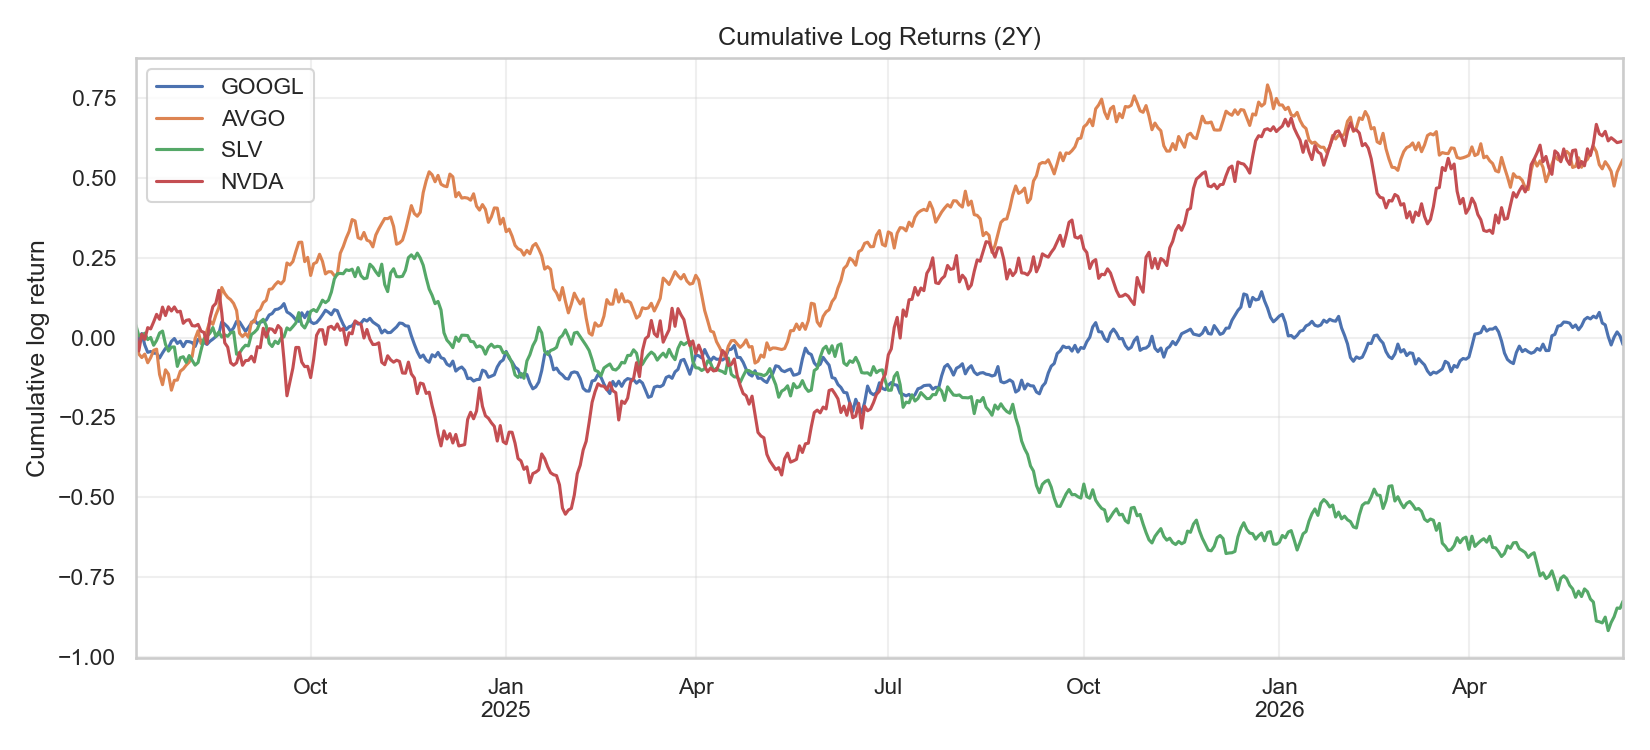

C:\Users\ltz\Projects\financial-analysis\images\correlation_heatmap.png


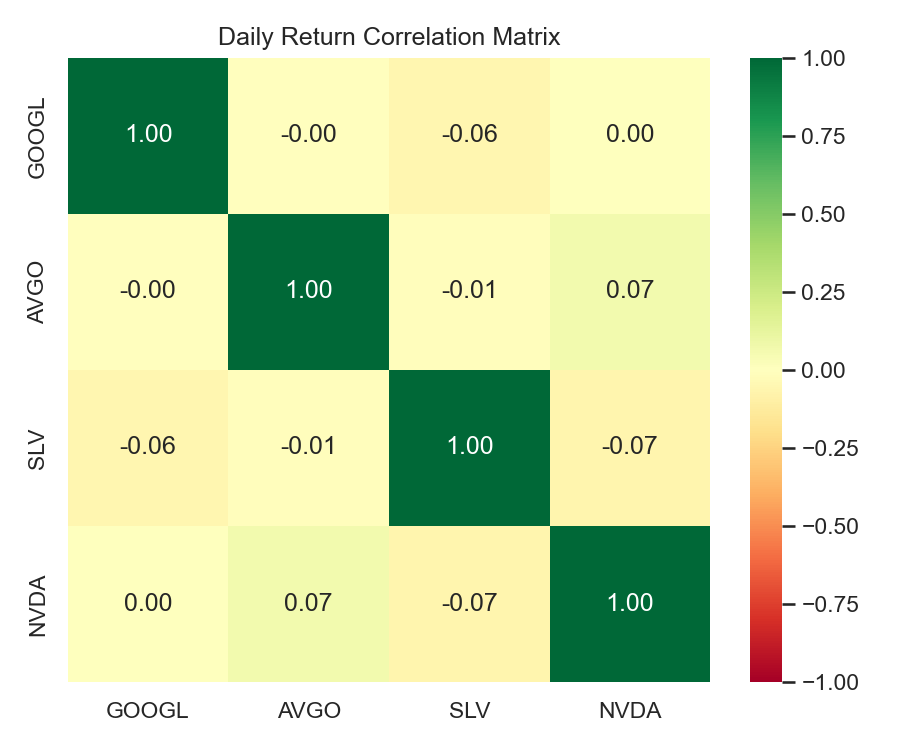

C:\Users\ltz\Projects\financial-analysis\images\rolling_volatility.png


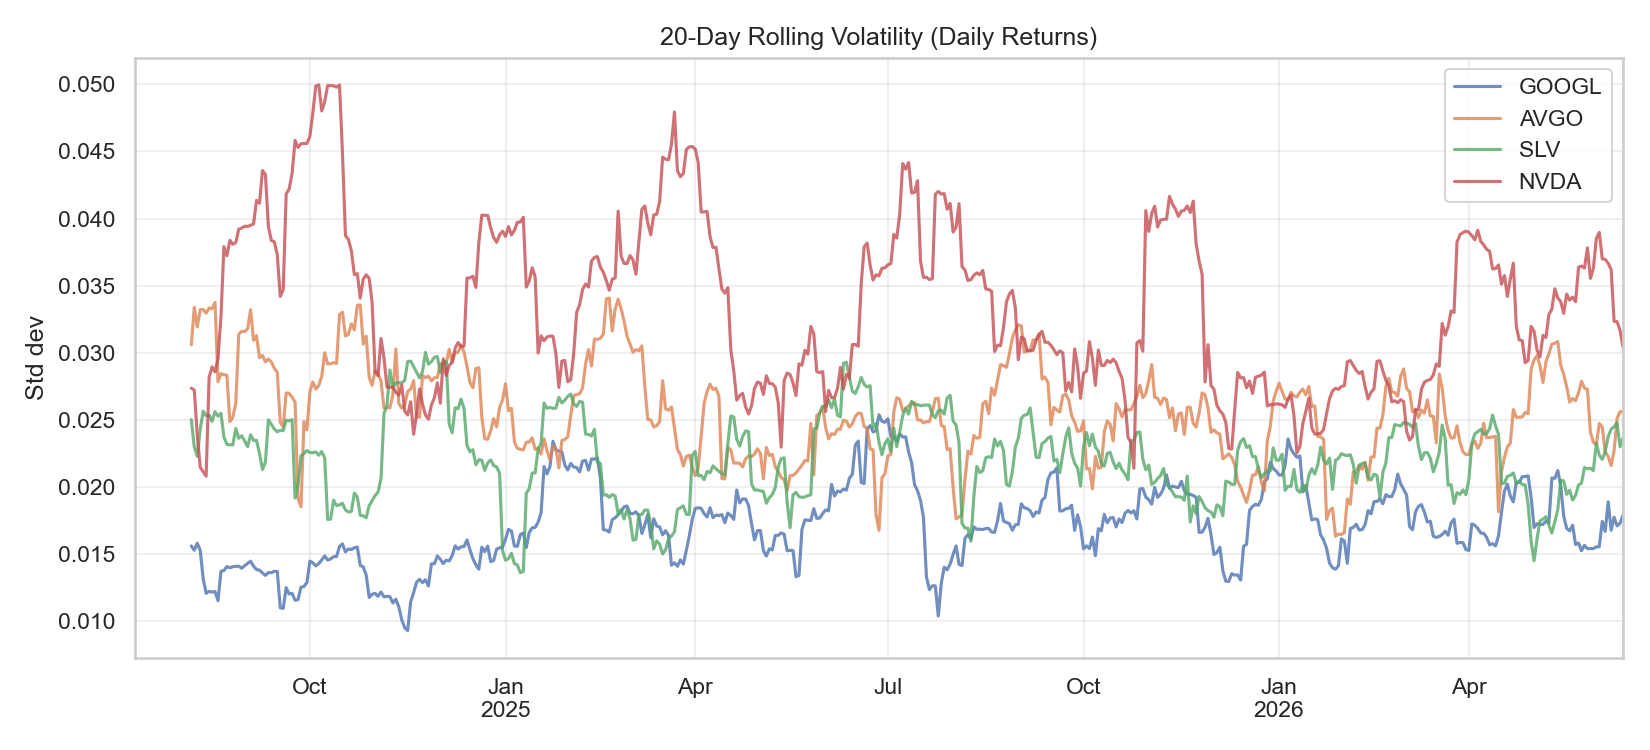

C:\Users\ltz\Projects\financial-analysis\images\monthly_returns_bar.png


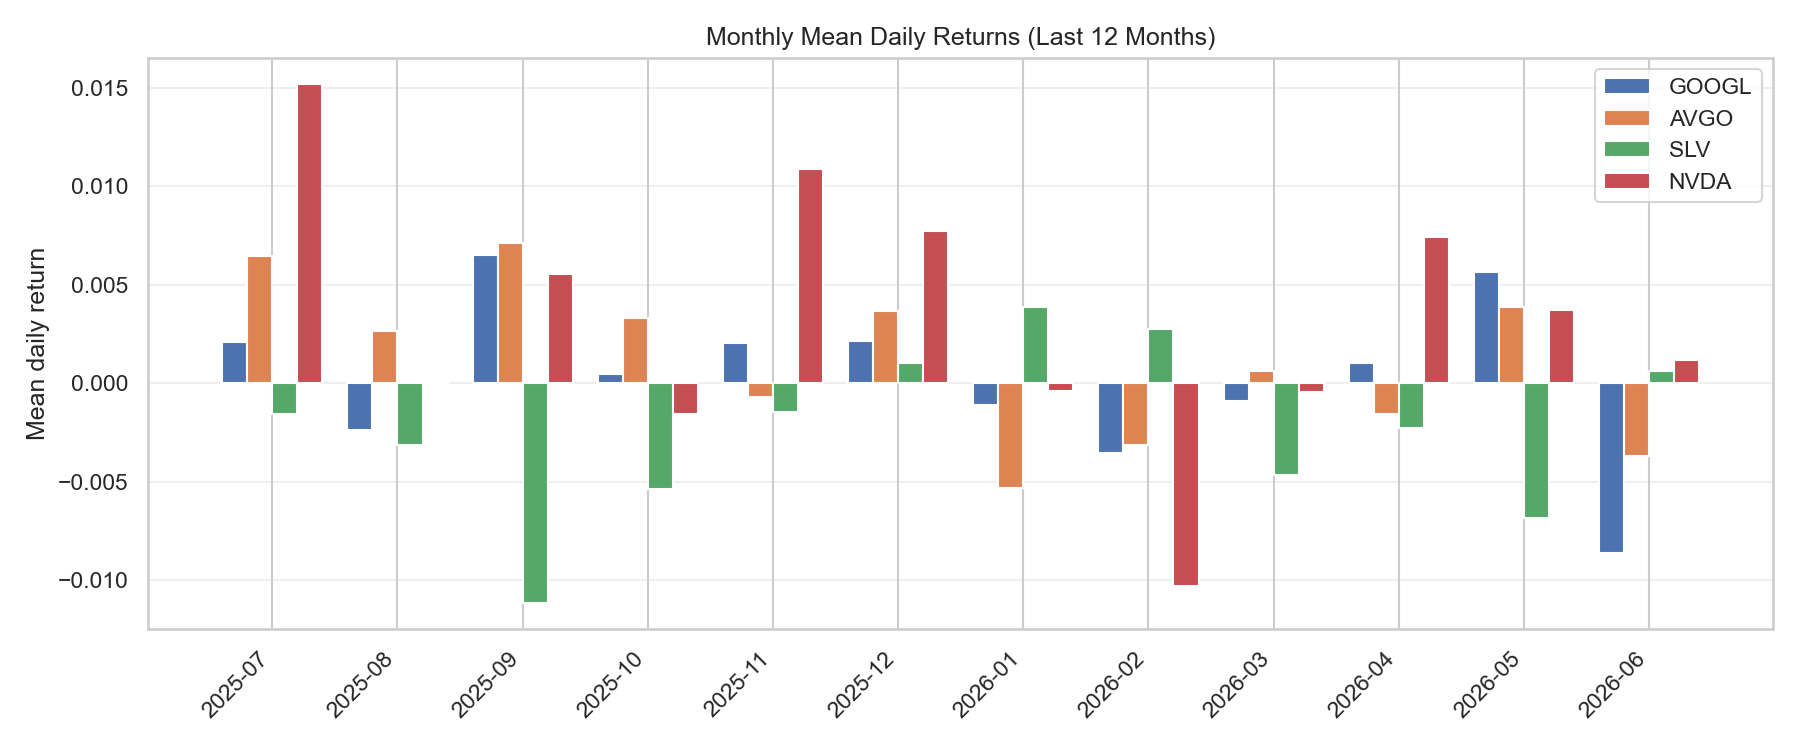

In [9]:
from IPython.display import Image, display

paths = generate_all_figures(results)
for p in paths:
    print(p)
    display(Image(filename=p))

### 分析结论（请根据你运行时的最新数字微调）

1. **波动最大：** 通常 NVDA 或 AVGO 的日收益标准差高于 GOOGL；SLV 作为商品 ETF，波动特征与科技股不同，需对照上方 `stats_loop` 表中的 `std` 列确认。
2. **相关性：** 三只科技股（GOOGL、AVGO、NVDA）日收益相关系数普遍为正且较高；SLV 与科技股相关性明显更低，体现股票与大宗商品的不同驱动因素。
3. **分布与平稳性：** Jarque-Bera 通常在 5% 水平拒绝日收益正态性（尖峰厚尾）；ADF 对价格水平多无法拒绝单位根（非平稳），对日收益则多显著平稳，符合金融时间序列常见结论。
4. **滚动波动率：** 2022–2024 期间市场大幅波动阶段，四只标的的 20 日滚动波动率均会出现尖峰；科技股尖峰往往与财报、利率或 AI 主题新闻同步，SLV 则更多反映贵金属价格与宏观预期。
5. **工程结构：** 数据采集在 `src/data_fetch.py`，分析逻辑在 `src/analysis.py`，统计工具在 `src/utils.py`，本 Notebook 负责展示与文字说明。